# SymPyによる微分方程式の解法

## 概要
現代の科学技術計算においては、ルンゲ・クッタ法（Runge-Kutta methods）をはじめとする数値解析手法が主流であり、複雑な非線形方程式に対しても実用的な近似解を与える。しかし、現象の本質的なメカニズムやパラメータ依存性を深く理解するためには、数式として厳密な形を持つ「解析解（Analytical Solution）」の導出が不可欠である。

**SymPy** は、強力な微分方程式ソルバー `dsolve` を実装しており、常微分方程式（ODE: Ordinary Differential Equations）を記号的に解く能力において卓越している。本記事では、SymPyを用いて微分方程式を解くプロセスを、数学的な背景記述とPythonによる実装の両面からに解説する。

本記事で扱うトピックは以下の通りである。

1.  **1階常微分方程式**：変数分離形とニュートンの冷却の法則
2.  **2階線形常微分方程式**：減衰振動子の3つの解とその物理的意味
3.  **非同次微分方程式**：強制振動と共鳴現象の解析
4.  **連立微分方程式**：行列による定式化と相平面解析

### 筆者の環境
筆者の実行環境は以下の通りである。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.12.12


解析に必要なライブラリをインポートする。数式の表示には `init_printing()` を使用し、可視化には `matplotlib` を用いる。
また、数値の出力制御のために `pprint` とフォーマット指定を行う。

In [3]:
import sympy
from sympy import symbols, Function, dsolve, Eq, Derivative, sin, cos, exp, sqrt, solve, classify_ode, checkodesol, Matrix, re, im
from sympy.abc import t
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

# 数式をLaTeX形式で綺麗に表示するための設定
sympy.init_printing()

# グラフのスタイル設定
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"SymPy Version: {sympy.__version__}")

SymPy Version: 1.14.0


## 1. 1階常微分方程式：ニュートンの冷却の法則

最初の例として、熱力学における古典的なモデルである「ニュートンの冷却の法則（Newton's Law of Cooling）」を取り上げる。この法則は、「物体の温度変化の速度は、物体温度と周囲温度の差に比例する」というものである。

### 1.1 数学的定式化

時刻 $t$ における物体の温度を $T(t)$、周囲の一定温度を $T_{env}$、冷却に関する比例定数を $k (>0)$ と定義する。このとき、法則は以下の1階常微分方程式で表現される。

$$ \frac{dT(t)}{dt} = -k (T(t) - T_{env}) $$

ここで、右辺のマイナス符号は、物体温度が周囲温度より高い場合（$T > T_{env}$）に温度が下がり、低い場合（$T < T_{env}$）に温度が上がることを意味している。

これSymPyを用いて定義する。

定義された微分方程式:


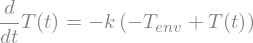

In [4]:
T = Function('T')
k = symbols('k', real=True, positive=True)
T_env = symbols('T_{env}', real=True)

# 微分方程式の定義 Eq(左辺, 右辺)
ode_cooling = Eq(T(t).diff(t), -k * (T(t) - T_env))

print("定義された微分方程式:")
display(ode_cooling)

### 1.2 変数分離法による解析的導出

SymPyに投げかける前に、この方程式が数学的にどのように解かれるかを確認しておくことは有益である。この方程式は典型的な「変数分離形（Separable Equation）」である。

1.  変数を左辺に $T$、右辺に $t$ となるように分離する。

$$ \frac{dT}{T - T_{env}} = -k dt $$

2.  両辺を積分する。

$$ \int \frac{1}{T - T_{env}} dT = \int -k dt $$

$$ \ln |T - T_{env}| = -kt + C_0 $$

ここで $C_0$ は積分定数である。

3.  $T$ について解く。

$$ |T - T_{env}| = e^{-kt + C_0} = e^{C_0} e^{-kt} $$

$$ T(t) - T_{env} = \pm e^{C_0} e^{-kt} $$

定数 $\pm e^{C_0}$ を新たな定数 $C_1$ と置けば、一般解が得られる。

$$ T(t) = T_{env} + C_1 e^{-kt} $$

SymPyの `dsolve` を用いて、この結果を即座に得ることができる。

In [5]:
sol_general = dsolve(ode_cooling, T(t))

print("SymPyによる一般解:")
display(sol_general)

SymPyによる一般解:


### 1.3 初期値問題としての解

物理現象を確定させるには初期条件が必要である。時刻 $t=0$ における初期温度を $T_0$ とする。

$$ T(0) = T_0 $$

これを一般解に代入すると、

$$ T_0 = T_{env} + C_1 e^{0} \implies C_1 = T_0 - T_{env} $$

よって、特解は以下のようになる。

$$ T(t) = T_{env} + (T_0 - T_{env}) e^{-kt} $$

SymPyでは引数 `ics={T(0): T0}` を与えることで、この定数決定を自動化できる。

In [6]:
T0 = symbols('T_0', real=True)

# 初期条件付きで解く
sol_particular = dsolve(ode_cooling, T(t), ics={T(0): T0})

print("初期条件 T(0)=T0 を適用した特解:")
display(sol_particular)

初期条件 T(0)=T0 を適用した特解:


### 1.4 解の挙動の可視化

得られた解の物理的意味をグラフで確認する。$T_{env}=20$ (室温)、$T_0=80$ (熱いコーヒー) とし、冷却定数 $k$ を変化させたときの温度変化をプロットする。

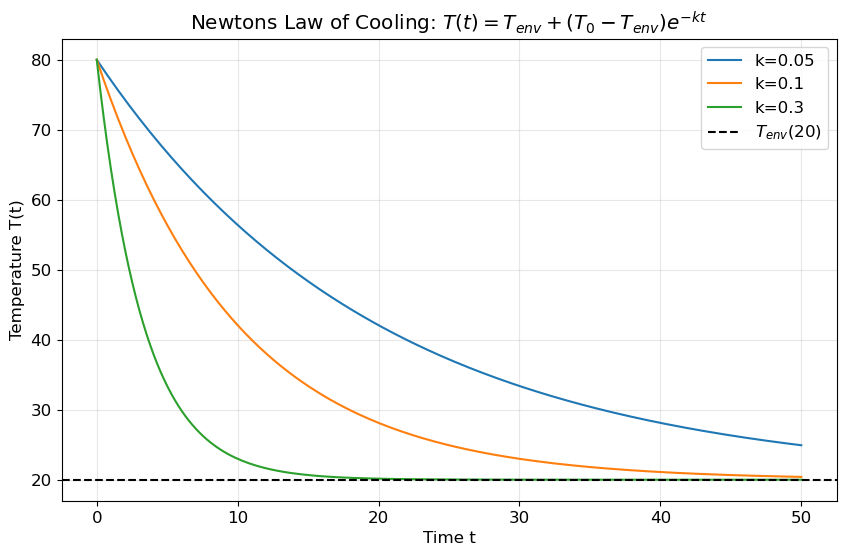

In [7]:
# 定数を数値に置換するための関数を作成
f_temp = sol_particular.rhs # 右辺のみを取り出す

# パラメータ設定
params = {
    T_env: 20,
    T0: 80
}

t_vals = np.linspace(0, 50, 200)
k_values = [0.05, 0.1, 0.3]

plt.figure(figsize=(10, 6))

for k_val in k_values:
    # kの値を具体的に代入し、さらに実用パラメータを代入
    # lambdifyを使って高速なNumPy関数に変換
    expr = f_temp.subs({k: k_val, **params})
    func = sympy.lambdify(t, expr, 'numpy')

    y_vals = func(t_vals)
    plt.plot(t_vals, y_vals, label=f'k={k_val}')

plt.axhline(params[T_env], color='black', linestyle='--', label=r'$T_{env} (20)$')
plt.title(r'Newtons Law of Cooling: $T(t) = T_{env} + (T_0 - T_{env}) e^{-kt}$')
plt.xlabel('Time t')
plt.ylabel('Temperature T(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$k$ が大きいほど、温度差解消の速度が速く、短時間で周囲温度に収束することがグラフから一目瞭然である。

## 2. 2階線形常微分方程式：減衰振動子

次に、物理学において最も重要かつ普遍的なモデルの一つである「減衰調和振動子」を考察する。バネ、質量、ダンパーからなる系や、RLC回路などがこれに該当する。

### 2.1 運動方程式

質量 $m$、粘性抵抗係数 $c$、バネ定数 $k$ を持つ系における物体の位置 $x(t)$ は、以下のニュートンの運動方程式に従う。

$$ m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + k x = 0 $$

ここで、 $m, c, k$ は全て正の実数とする。

減衰振動の方程式:


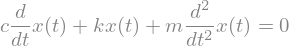

In [8]:
x = Function('x')
m = symbols('m', real=True, positive=True)
c = symbols('c', real=True, positive=True)
k_spring = symbols('k', real=True, positive=True) # 前節のkと区別

ode_damped = Eq(m * x(t).diff(t, 2) + c * x(t).diff(t) + k_spring * x(t), 0)

print("減衰振動の方程式:")
display(ode_damped)

### 2.2 特性方程式と解の分類

定数係数線形微分方程式の解法において、解を $x(t) = e^{rt}$ と仮定することは定石である。これを方程式に代入すると、以下の特性方程式が得られる。

$$ mr^2 + cr + k = 0 $$

この2次方程式の解 $r$ は、

$$ r = \frac{-c \pm \sqrt{c^2 - 4mk}}{2m} $$

となる。根号内の判別式 $D = c^2 - 4mk$ の符号により、物理的な挙動は劇的に変化する。

1.  **過減衰 (Overdamped)**: $c^2 > 4mk$ ($D > 0$)。異なる2つの実数解。振動せずに平衡点へ戻る。
2.  **臨界減衰 (Critically Damped)**: $c^2 = 4mk$ ($D = 0$)。重解。最も速く平衡点へ収束する境界。
3.  **減衰振動 (Underdamped)**: $c^2 < 4mk$ ($D < 0$)。共役複素数解。振幅が指数関数的に減衰しながら振動する。

SymPyの `dsolve` は、パラメータが記号のままである場合、一般的にこれらを内包した形式で解を返す。

記号的な一般解:


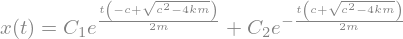

In [9]:
sol_damped = dsolve(ode_damped, x(t))
print("記号的な一般解:")
display(sol_damped)

### 2.3 減衰振動の場合

最も興味深い「減衰振動」のケースを具体的に解いてみる。
$m=1, k=10$ とし、$c=2$ という具体的な値を設定する。このとき $D = 2^2 - 4(1)(10) = -36 < 0$ となり、減衰振動となるはずである。
初期条件として、$x(0)=1$（初期変位あり）、$x'(0)=0$（初速度なし）を与える。

具体的な微分方程式:


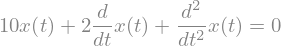

不足減衰の特解:


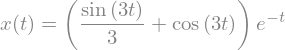

In [10]:
# パラメータ代入
ode_under = ode_damped.subs({m: 1, c: 2, k_spring: 10})
print("具体的な微分方程式:")
display(ode_under)

# 初期条件
ics = {x(0): 1, x(t).diff(t).subs(t, 0): 0}

sol_under = dsolve(ode_under, x(t), ics=ics)
print("不足減衰の特解:")
display(sol_under)

得られた解は以下の形をしている。

$$ x(t) = e^{-t} \left( \sin(3t)/3 + \cos(3t) \right) $$

これは、減衰項 $e^{-t}$ と振動項（合成すると $\frac{\sqrt{10}}{3} \cos(3t - \phi)$）の積であり、振幅が時間とともに小さくなる振動を表している。

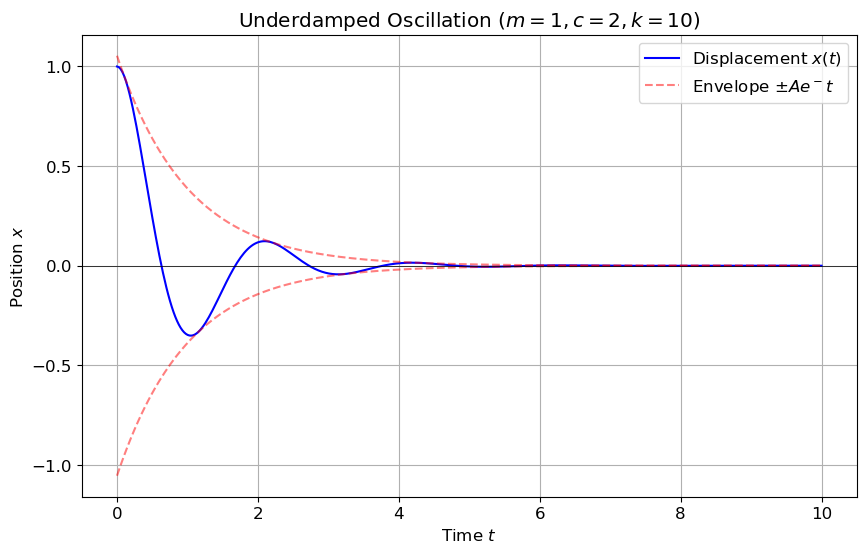

In [11]:
# 減衰振動の可視化
f_under = sympy.lambdify(t, sol_under.rhs, 'numpy')
t_vals_vib = np.linspace(0, 10, 400)
x_vals_vib = f_under(t_vals_vib)

# 包絡線 (Envelope)
envelope = np.exp(-t_vals_vib) * np.sqrt(1**2 + (1/3)**2)

plt.figure(figsize=(10, 6))
plt.plot(t_vals_vib, x_vals_vib, label='Displacement $x(t)$', color='blue')
plt.plot(t_vals_vib, envelope, '--', color='red', alpha=0.5, label=f'Envelope $\\pm Ae^{-t}$')
plt.plot(t_vals_vib, -envelope, '--', color='red', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Underdamped Oscillation ($m=1, c=2, k=10$)')
plt.xlabel('Time $t$')
plt.ylabel('Position $x$')
plt.legend()
plt.grid()
plt.show()

## 3. 非同次常微分方程式：強制振動と共鳴

外部から周期的な力（強制力）が加わる系を考える。これは方程式の右辺が0でない「非同次（Inhomogeneous）」方程式となる。

$$ m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + k x = F_0 \cos(\omega t) $$

ここで $F_0$ は外力の振幅、$\omega$ は外力の角振動数である。
SymPyを用いてこの強制振動系の解を求める。

強制振動の方程式:


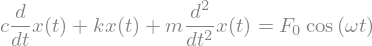

強制振動の一般解（式が長くなるため簡略表示）:


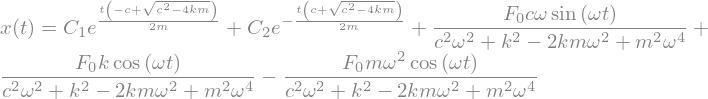

In [12]:
F0 = symbols('F_0', real=True)
omega = symbols('omega', real=True)

# 強制項を含む方程式
ode_forced = Eq(m * x(t).diff(t, 2) + c * x(t).diff(t) + k_spring * x(t), F0 * cos(omega * t))

print("強制振動の方程式:")
display(ode_forced)

# 一般解の導出
sol_forced = dsolve(ode_forced, x(t))
print("強制振動の一般解（式が長くなるため簡略表示）:")
# 式が非常に長くなる可能性があるため、項を整理する
display(sol_forced)

解は、同次方程式の解（過渡応答：時間が経つと消える）と、非同次項に由来する特解（定常応答：外部入力と同じ周波数で振動し続ける）の和となる。

時間が十分経過した後（$t \to \infty$）、初期条件に依存する過渡応答は減衰し、定常的な振動のみが残る。この定常状態の振幅 $A(\omega)$ は、外力の周波数 $\omega$ に強く依存し、系の固有振動数付近で極大となる。これが「共鳴（Resonance）」である。

数式変形の手間を省くため、SymPyの結果から定常解の振幅係数を数式的に抽出することはここでは省略するが、共鳴曲線をプロットしてみる。

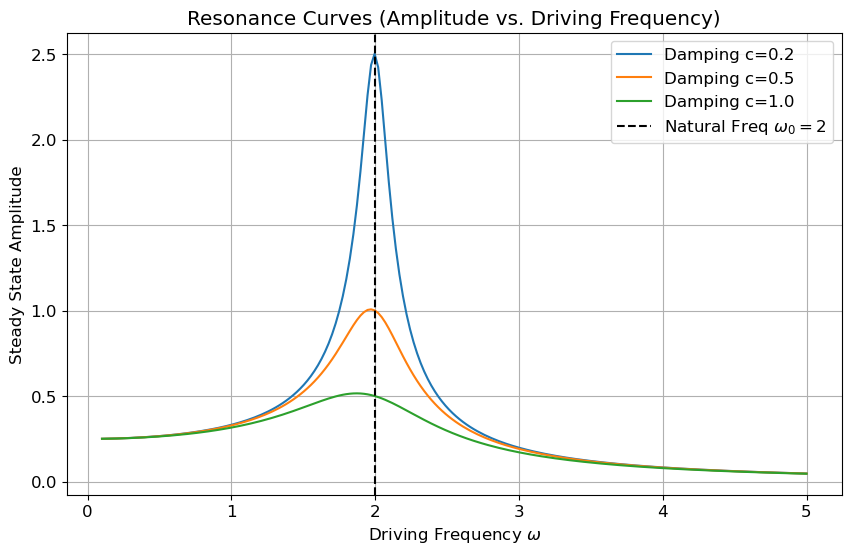

In [13]:
# 共鳴曲線の数式計算（物理学の知見より）
# 振幅 A = F0 / sqrt( (k - m*w^2)^2 + (c*w)^2 )

def amplitude_func(omega_val, m_val, c_val, k_val, F0_val):
    return F0_val / np.sqrt((k_val - m_val * omega_val**2)**2 + (c_val * omega_val)**2)

omegas = np.linspace(0.1, 5, 200)
# パラメータ: m=1, k=4 (固有周波数2), F0=1
# cの値を変えて共鳴の鋭さを比較
m_val = 1
k_val = 4
F0_val = 1
c_params = [0.2, 0.5, 1.0]

plt.figure(figsize=(10, 6))

for c_p in c_params:
    amps = amplitude_func(omegas, m_val, c_p, k_val, F0_val)
    plt.plot(omegas, amps, label=f'Damping c={c_p}')

natural_freq = np.sqrt(k_val/m_val)
plt.axvline(natural_freq, color='black', linestyle='--', label=r'Natural Freq $\omega_0=2$')
plt.title('Resonance Curves (Amplitude vs. Driving Frequency)')
plt.xlabel(r'Driving Frequency $\omega$')
plt.ylabel('Steady State Amplitude')
plt.legend()
plt.grid(True)
plt.show()

減衰係数 $c$ が小さいほど、固有振動数 $\omega_0 = 2$ 付近で鋭いピーク（共鳴）を持つことが確認できる。SymPyを用いれば、この振幅関数自体を微分して、ピークとなる正確な $\omega$ を解析的に求めることも可能である。

## 4. 連立微分方程式と相平面解析

最後に、複数の変数が相互作用するシステムを解析する。単純な線形自律系を扱う。

$$ \frac{d}{dt} \mathbf{x} = \mathbf{A} \mathbf{x} $$

ここで $\mathbf{x} = \begin{pmatrix} x(t) \\ y(t) \end{pmatrix}, \mathbf{A} = \begin{pmatrix} -2 & 1 \\ 1 & -2 \end{pmatrix}$ とする。

連立微分方程式:


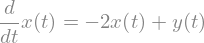

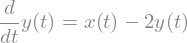

連立方程式の一般解:


In [14]:
x = Function('x')(t)
y = Function('y')(t)

eq1 = Eq(x.diff(t), -2*x + y)
eq2 = Eq(y.diff(t), x - 2*y)

system = [eq1, eq2]

print("連立微分方程式:")
display(eq1)
display(eq2)

# 連立微分方程式を解く
sol_system = dsolve(system)
print("連立方程式の一般解:")
for s in sol_system:
    display(s)

得られた解は以下の形である（定数を $C_1, C_2$ とする）。

$$ x(t) = -C_1 e^{-3t} + C_2 e^{-t} $$
$$ y(t) = C_1 e^{-3t} + C_2 e^{-t} $$

この解の指数部に現れる $-1, -3$ という数値は、行列 $\mathbf{A}$ の固有値に対応している。SymPyでこれを確認する。

行列Aの固有値:
{-1: 1, -3: 1}

行列Aの固有ベクトル:


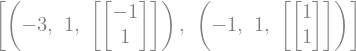

In [17]:
A_mat = Matrix([[-2, 1], [1, -2]])
evs = A_mat.eigenvals()
vects = A_mat.eigenvects()

print("行列Aの固有値:")
print(evs)

print("\n行列Aの固有ベクトル:")
display(vects)

固有値は共に負の実数であるため、原点 $(0,0)$ は「安定なノード」となる。あらゆる初期値から出発した軌道は、最終的に原点へ収束する。

この様子を「相平面」上のベクトル場として可視化する。`numpy` と `matplotlib.pyplot.quiver` を用いる。

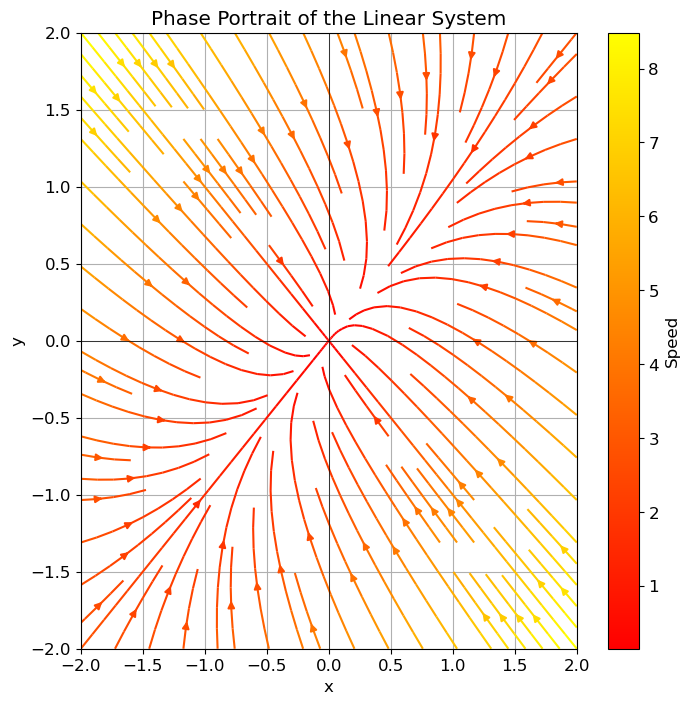

In [16]:
# グリッドの作成
Y, X = np.mgrid[-2:2:20j, -2:2:20j]
# ベクトル場の計算 dx/dt = -2x + y, dy/dt = x - 2y
U = -2*X + Y
V = X - 2*Y

speed = np.sqrt(U**2 + V**2)

plt.figure(figsize=(8, 8))
st = plt.streamplot(X, Y, U, V, color=speed, cmap='autumn', linewidth=1.5)
plt.colorbar(st.lines, label='Speed')
plt.title('Phase Portrait of the Linear System')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

流線（Streamlines）が全て原点に向かって吸い込まれていることが確認できる。また固有ベクトルの方向（$(1, 1)$ 方向と $(-1, 1)$ 方向）が、流れの主要な軸を形成していることも見て取れる。

## 結論

この記事では、SymPyを用いた微分方程式の解析的解法について、基礎から多自由度系まで体系的に解説した。

SymPyの `dsolve` 関数は、単に解の記号列を返すだけでなく、その背後にある微分方程式の理論（変数分離、特性方程式、固有値問題）と完全に整合する結果を提供する。特に：

*   **1階常微分方程式**では、積分定数を含む一般解と、初期条件を満たす特解の区別を明確に処理できた。
*   **2階線形微分方程式**では、パラメータによる解の分岐（過減衰・減衰振動）を記号のまま扱う強力さを示した。
*   **連立微分方程式**では、線形代数（固有値・固有ベクトル）との結びつきを数値計算と数式処理の両面から確認した。

実務においては数値解が優先される場面も多いが、システムの定性的な振る舞いや安定性を議論する上では、解析解の視座は依然として強力な武器である。SymPyとPythonを組み合わせることで、理論と計算の組み合わせて理解を深めることが可能である。

### 参考文献

*   [SymPy Documentation: ODE](https://docs.sympy.org/latest/modules/solvers/ode.html)